In [57]:
from kerasAC.custom_losses import *
import tiledb
from kerasAC.tiledb_config import get_default_config


In [58]:
import numpy as np 
import pandas as pd 
import matplotlib

In [59]:
tdb_path="/mnt/data/encode_dnase_tiledb/db/dnase/ENCSR000EOT"
chrom='chr1'
label_attribute='count_bigwig_unstranded_5p'
ambig_attribute='ambig_peak'
upsample_attribute='idr_peak'
tdb_partition_thresh_for_upsample=1 #upsample summits 



In [60]:
tdb_config=get_default_config()


In [61]:
ctx=tiledb.Ctx(tdb_config)


In [62]:
tdb_array=tiledb.DenseArray(tdb_path+"."+chrom,mode='r',ctx=ctx)


In [63]:
vals=tdb_array[:]


In [64]:
labs=vals[label_attribute]

In [65]:
ambig=vals[ambig_attribute]

In [66]:
upsample=vals[upsample_attribute]

In [67]:
indices_for_training=np.where(np.logical_and(ambig == 0, upsample >= tdb_partition_thresh_for_upsample))[0]

In [68]:
indices_for_training

array([   629093,    629094,    629095, ..., 248927143, 248927144,
       248927145])

In [69]:
flank=500

In [70]:
processed=0
counts=[] 
for index in indices_for_training: 
    counts.append(np.sum(labs[index-flank:index+flank]))
    processed+=1
    if processed%1000==0: 
        print(processed)
counts=np.array(counts)

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
155000
156000
157000
158000
15

1187000
1188000
1189000
1190000
1191000
1192000
1193000
1194000
1195000
1196000
1197000
1198000
1199000
1200000
1201000
1202000
1203000
1204000
1205000
1206000
1207000
1208000
1209000
1210000
1211000
1212000
1213000
1214000
1215000
1216000
1217000
1218000
1219000
1220000
1221000
1222000
1223000
1224000
1225000
1226000
1227000
1228000
1229000
1230000
1231000
1232000
1233000
1234000
1235000
1236000
1237000
1238000
1239000
1240000
1241000
1242000
1243000
1244000
1245000
1246000
1247000
1248000
1249000
1250000
1251000
1252000
1253000
1254000
1255000
1256000
1257000
1258000
1259000
1260000
1261000
1262000
1263000
1264000
1265000
1266000
1267000
1268000
1269000
1270000
1271000
1272000
1273000
1274000
1275000
1276000
1277000
1278000
1279000
1280000
1281000
1282000
1283000
1284000
1285000
1286000
1287000
1288000
1289000
1290000
1291000
1292000
1293000
1294000
1295000
1296000
1297000
1298000
1299000
1300000
1301000
1302000
1303000
1304000
1305000
1306000
1307000
1308000
1309000
1310000
1311000


2240000
2241000
2242000
2243000
2244000
2245000
2246000
2247000
2248000
2249000
2250000
2251000
2252000
2253000
2254000
2255000
2256000
2257000
2258000
2259000
2260000
2261000
2262000
2263000
2264000
2265000
2266000
2267000
2268000
2269000
2270000
2271000
2272000
2273000
2274000
2275000
2276000
2277000
2278000
2279000
2280000
2281000
2282000
2283000
2284000
2285000
2286000
2287000
2288000
2289000
2290000
2291000
2292000
2293000
2294000
2295000
2296000
2297000
2298000
2299000
2300000
2301000
2302000
2303000
2304000
2305000
2306000
2307000
2308000
2309000
2310000
2311000
2312000
2313000
2314000
2315000
2316000
2317000
2318000
2319000
2320000
2321000
2322000
2323000
2324000
2325000
2326000
2327000
2328000
2329000
2330000
2331000
2332000
2333000
2334000
2335000
2336000
2337000
2338000
2339000
2340000
2341000
2342000
2343000
2344000
2345000
2346000
2347000
2348000
2349000
2350000
2351000
2352000
2353000
2354000
2355000
2356000
2357000
2358000
2359000
2360000
2361000
2362000
2363000
2364000


3296000
3297000
3298000
3299000
3300000
3301000
3302000
3303000
3304000
3305000
3306000
3307000
3308000
3309000
3310000
3311000
3312000
3313000
3314000
3315000
3316000
3317000
3318000
3319000
3320000
3321000
3322000
3323000
3324000
3325000
3326000
3327000
3328000
3329000
3330000
3331000
3332000
3333000
3334000
3335000
3336000
3337000
3338000
3339000
3340000
3341000
3342000
3343000
3344000
3345000
3346000
3347000
3348000
3349000
3350000
3351000
3352000
3353000
3354000
3355000
3356000
3357000
3358000
3359000
3360000
3361000
3362000
3363000
3364000
3365000
3366000
3367000
3368000
3369000
3370000
3371000
3372000
3373000
3374000
3375000
3376000
3377000
3378000
3379000
3380000
3381000
3382000
3383000
3384000
3385000
3386000
3387000
3388000
3389000
3390000
3391000
3392000
3393000
3394000
3395000
3396000
3397000
3398000
3399000
3400000
3401000
3402000
3403000
3404000
3405000
3406000
3407000
3408000
3409000
3410000
3411000
3412000
3413000
3414000
3415000
3416000
3417000
3418000
3419000
3420000


4350000
4351000
4352000
4353000
4354000
4355000
4356000
4357000
4358000
4359000
4360000
4361000
4362000
4363000
4364000
4365000
4366000
4367000
4368000
4369000
4370000
4371000
4372000
4373000
4374000
4375000
4376000
4377000
4378000
4379000
4380000
4381000
4382000
4383000
4384000
4385000
4386000
4387000
4388000
4389000
4390000
4391000
4392000
4393000
4394000
4395000
4396000
4397000
4398000
4399000
4400000
4401000
4402000
4403000
4404000
4405000
4406000
4407000
4408000
4409000
4410000
4411000
4412000
4413000
4414000
4415000
4416000
4417000
4418000
4419000
4420000
4421000
4422000
4423000
4424000
4425000
4426000
4427000
4428000
4429000
4430000
4431000
4432000
4433000
4434000
4435000
4436000
4437000
4438000
4439000
4440000
4441000
4442000
4443000
4444000
4445000
4446000
4447000
4448000
4449000
4450000
4451000
4452000
4453000
4454000
4455000
4456000
4457000
4458000
4459000
4460000
4461000
4462000
4463000
4464000
4465000
4466000
4467000
4468000
4469000
4470000
4471000
4472000
4473000
4474000


In [71]:
print('median:'+str(np.median(counts)))
print('mean:'+str(np.mean(counts)))
print('std:'+str(np.std(counts)))
print('min:'+str(np.min(counts)))
print('max:'+str(np.max(counts)))
print('num summits:'+str(len(counts)))

median:2635.0
mean:5854.0464
std:16610.52
min:0.0
max:1309033.0
num summits:4783331


In [72]:
from scipy.stats import iqr

In [73]:
counts_iqr=iqr(counts)

In [74]:
counts_iqr

5974.0

In [80]:
counts_low=counts[counts<100000]

In [86]:
print('median:'+str(np.median(counts_low)))
print('mean:'+str(np.mean(counts_low)))
print('std:'+str(np.std(counts_low)))
print('min:'+str(np.min(counts_low)))
print('max:'+str(np.max(counts_low)))
print('num summits:'+str(len(counts_low)))

median:2633.0
mean:5651.551
std:7245.0034
min:0.0
max:99009.0
num summits:4781739


In [81]:
counts_asinh=np.arcsinh(counts)

In [82]:
counts_log10=np.log10(counts+0.001)

In [83]:
counts_log2=np.log2(counts+0.001)

<Figure size 1440x1280 with 0 Axes>

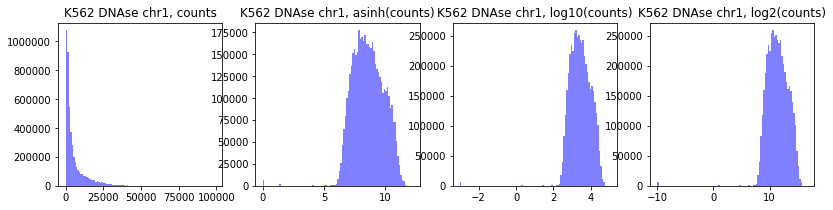

In [85]:
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 16), dpi= 80, facecolor='w', edgecolor='k')

figure, axes = plt.subplots(figsize=(14,3),nrows=1,ncols=4)
num_bins = 100
# the histogram of the data
axes[0].hist(counts, num_bins, facecolor='blue', alpha=0.5)
axes[0].set_title('K562 DNAse '+chrom+', counts')
axes[1].hist(counts_asinh, num_bins, facecolor='blue', alpha=0.5,)
axes[1].set_title('K562 DNAse '+chrom+', asinh(counts)')
axes[2].hist(counts_log10, num_bins, facecolor='blue', alpha=0.5)
axes[2].set_title('K562 DNAse '+chrom+', log10(counts)')
axes[3].hist(counts_log2, num_bins, facecolor='blue', alpha=0.5)
axes[3].set_title('K562 DNAse '+chrom+', log2(counts)')

# Tweak spacing to prevent clipping of ylabel
plt.subplots_adjust(left=0.15)
plt.show()

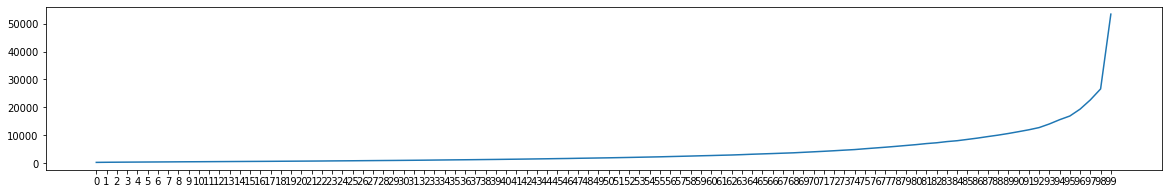

In [20]:
quantiles=np.quantile(counts, np.arange(0.01,1.01,0.01))
figure, axes = plt.subplots(figsize=(20,3),nrows=1)
axes.plot(quantiles)
axes.set_xticks(np.arange(0,100,1))


In [21]:
import pandas as pd
counts_df=pd.DataFrame({'chr':chrom,'summit':indices_for_training,'region_start':indices_for_training-500,'region_end':indices_for_training+500,'count':counts})

In [22]:
counts_df.head()

,chr,summit,region_start,region_end,count
0,chr3,354538,354038,355038,942.0
1,chr3,632747,632247,633247,1262.0
2,chr3,1082231,1081731,1082731,416.0
3,chr3,1439607,1439107,1440107,326.0
4,chr3,2156407,2155907,2156907,660.0


In [23]:
counts_df.sort_values(by='count',ascending=False).head(n=20)

,chr,summit,region_start,region_end,count
1482,chr3,33440608,33440108,33441108,53436.0
291,chr3,9396708,9396208,9397208,53414.0
1578,chr3,36993449,36992949,36993949,52592.0
292,chr3,9396813,9396313,9397313,51179.0
1577,chr3,36993235,36992735,36993735,50204.0
1483,chr3,33440905,33440405,33441405,50164.0
293,chr3,9397005,9396505,9397505,49676.0
290,chr3,9396627,9396127,9397127,49521.0
1693,chr3,38165094,38164594,38165594,48485.0
1481,chr3,33440487,33439987,33440987,46953.0


In [24]:
##allchroms

In [34]:
chroms=[]
medians=[]
means=[] 
stdevs=[] 
mins=[]
maxes=[]
summit_counts=[]
top20=None

In [35]:
for chrom in list(range(1,23))+['X','Y']:
    chrom='chr'+str(chrom)
    print(chrom)
    tdb_array=tiledb.DenseArray(tdb_path+"."+chrom,mode='r',ctx=ctx)
    vals=tdb_array[:]
    labs=vals[label_attribute]
    ambig=vals[ambig_attribute]
    upsample=vals[upsample_attribute]
    indices_for_training=np.where(np.logical_and(ambig == 0, upsample >= tdb_partition_thresh_for_upsample))[0]
    flank=500
    counts=[] 
    for index in indices_for_training: 
        counts.append(np.sum(labs[index-flank:index+flank]))
    counts=np.array(counts)
    chroms.append(chrom)
    medians.append(np.median(counts))
    means.append(np.mean(counts))
    stdevs.append(np.std(counts))
    mins.append(np.min(counts))
    maxes.append(np.max(counts))
    summit_counts.append(len(counts))
    counts_df=pd.DataFrame({'chr':chrom,
                            'summit':indices_for_training,
                            'region_start':indices_for_training-500,
                            'region_end':indices_for_training+500,
                            'count':counts})
    counts_df_top=counts_df.sort_values(by='count',ascending=False).iloc[0:20]
    if top20 is None: 
        top20=counts_df_top 
    else: 
        top20=pd.concat([top20,counts_df_top],axis=0)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
chr21
chr22
chrX
chrY


In [31]:
top5


,chr,summit,region_start,region_end,count
10,chr1,634415,633915,634915,1308944.0
7,chr1,634042,633542,634542,1308872.0
8,chr1,634177,633677,634677,1308818.0
9,chr1,634300,633800,634800,1308739.0
4,chr1,630274,629774,630774,172751.0
...,...,...,...,...,...
4,chrY,10912922,10912422,10913422,464.0
3,chrY,9141929,9141429,9142429,274.0
2,chrY,4344817,4344317,4345317,196.0
0,chrY,4030753,4030253,4031253,2.0


In [37]:
top20.to_csv("top20_summit_regions_for_5prime_count_K562_DNAse.tsv",sep='\t',header=True,index=False)

In [38]:
stats_df=pd.DataFrame({'chrom':chroms,
                       'medians':medians,
                      'means':means,
                      'stdevs':stdevs,
                      'min':mins,
                      'max':maxes,
                      'numpeaks':summit_counts})



In [40]:
stats_df.to_csv("stats_df_by_chrom.tsv",header=True,index=False)